In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

sns.set(style="whitegrid", context="talk")
DATA_PATH = Path("/home/ahallur1/spear/Seamless_Experiments/Lexical/seamless_lexical_features.csv")
MIN_WORDS_FOR_LD = 50
HIGH_CONF_THRESH = 0.7

In [16]:
df = pd.read_csv(DATA_PATH)
print(df.shape)


df["length_bin"] = pd.cut(
    df["total_words"],
    bins=[0, 50, 100, 300, 1000, np.inf],
    labels=["<50", "50–100", "100–300", "300–1000", ">1000"],
    )

(129215, 20)


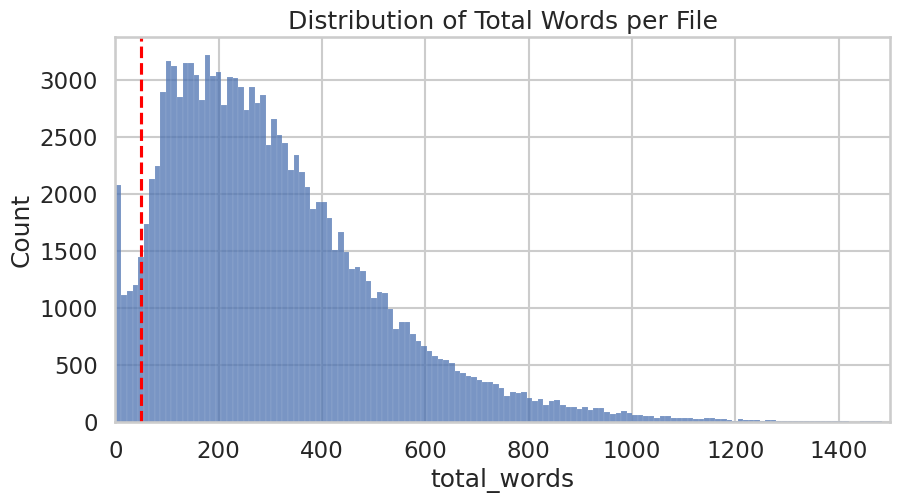

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df["total_words"], bins=800)
plt.axvline(MIN_WORDS_FOR_LD, color="red", linestyle="--")
plt.xlim(0, 1500)
plt.title("Distribution of Total Words per File")
plt.show()

In [18]:
LEX_CSV = Path("/home/ahallur1/spear/Seamless_Experiments/Lexical/seamless_lexical_features.csv")
assert LEX_CSV.exists()

df_lex = pd.read_csv(LEX_CSV)
print(f"Lexical rows: {len(df_lex):,}")


Lexical rows: 129,215


In [19]:
VOX_CSV = Path(
    "/home/ahallur1/spear/Vox_Profile/vox-profile-release/csv_shards/participant_vox_profile_file_level.csv"
)
assert VOX_CSV.exists()

df_vox = pd.read_csv(VOX_CSV)
print(f"Vox-profile rows: {len(df_vox):,}")


Vox-profile rows: 124,184


In [20]:
df_lex = df_lex.merge(
    df_vox,
    on="wav_path",
    how="left",
    validate="one_to_one"
)

print(f"Merged lexical rows: {len(df_lex):,}")


Merged lexical rows: 129,215


In [21]:
print(df_lex.columns.tolist())

['orig_id', 'wav_path', 'lexical_status', 'status_reason', 'total_words', 'unique_words', 'mean_asr_confidence', 'low_conf_flag', 'content_word_count', 'function_word_count', 'lexical_density', 'ttr', 'mattr_small', 'mattr_large', 'mattr_ratio', 'mtld', 'hapax_ratio', 'lexical_entropy', 'backchannel_ratio', 'discourse_marker_ratio', 'age_years', 'gender', 'gender_confidence', 'arousal', 'valence', 'dominance', 'num_chunks_used', 'total_speech_sec', 'used_only_15s_chunks']


In [22]:
df_lex_dem = df_lex[
    (df_lex["age_years"].notna()) &
    (df_lex["gender"].notna()) &
    (df_lex["gender_confidence"] >= 0.5)
].copy()

print(f"Usable lexical rows after filtering: {len(df_lex_dem):,}")
df_lex_dem["gender"].value_counts()


Usable lexical rows after filtering: 0


Series([], Name: count, dtype: int64)